# This notebook shows how to compute orbital-character (s, p, d, f) projection operators and apply them to wavefunctions
### Import the necessary libraries

In [1]:
%matplotlib inline
import numpy as np
import matplotlib.pyplot as plt

from elkpy.structure import Structure
from elkpy.session import ORBITAL_LABELS

### The $\ell$-resolved atom-projection operator
Splitting the atom-projection operator $P_\alpha$ (previous notebook) by angular momentum before summing over $m$ gives, for $\ell=0,1,2,3$ (s, p, d, f)
$$ (P_{\alpha,\ell})_{ij}=\sum_{m=-\ell}^{\ell}\sum_\sigma\int_0^{R_\alpha}\psi_{i,\ell m\sigma}^*(r)\,\psi_{j,\ell m\sigma}(r)\,r^2\,dr, \qquad \sum_{\ell=0}^3 P_{\alpha,\ell}\preceq P_\alpha $$
the familiar "orbital character" of a band -- how much of a state's weight on atom $\alpha$ has s/p/d/f symmetry -- generalized here to an off-diagonal operator applicable to any wavefunction, not just a per-state weight table.

In [2]:
SI_AVEC = [(5.13, 5.13, 0.00), (5.13, 0.00, 5.13), (0.00, 5.13, 5.13)]
SI_SPECIES = {"Si": [(0.0, 0.0, 0.0), (0.25, 0.25, 0.25)]}
si = Structure(SI_AVEC, SI_SPECIES).get_calculation("_scratch/si_orbitalproj", xc="PW", ngridk=(4, 4, 4))

orb = si.get_orbital_projection((0.1, 0.2, 0.05), ist0=1, ist1=4)
orb.matrices.shape  # (natmtot, 4, nst, nst) -- l axis order given by ORBITAL_LABELS

(2, 4, 4, 4)

### Orbital character across bands: monolayer h-BN
The occupied valence-top ($\pi$) band at K is a nitrogen $2p_z$ state; a much deeper bonding ($\sigma$-type) valence band is nitrogen $2s$-dominated instead -- the dominant channel flips between the two bands of the *same* atom. Shown below as a full band structure colored by N's s- and p-weight, so the flip is visible across every band along the path, not just the two picked at K.

In [3]:
import re

A, VACUUM = 4.743210000, 20.0  # Bohr, same hBN slab as 05_berry_curvature.ipynb
HBN_AVEC = [(A, 0.0, 0.0), (-A / 2, A * 3 ** 0.5 / 2, 0.0), (0.0, 0.0, VACUUM)]
HBN_SPECIES = {"B": [(1 / 3, 2 / 3, 0.5)], "N": [(2 / 3, 1 / 3, 0.5)]}

hbn = Structure(HBN_AVEC, HBN_SPECIES).get_calculation("_scratch/hbn_orbitalproj", xc="PW", ngridk=(6, 6, 1), rgkmax=7.0)
hbn.get_energy()

first_block = (hbn.workdir / "EIGVAL.OUT").read_text().split("k-point")[1]
state_line = re.compile(r"^\s*\d+\s+(\S+)\s+(\S+)\s*$")
occ = [float(m.group(2)) for m in map(state_line.match, first_block.splitlines()) if m]
ist1 = sum(o > 1.0 for o in occ)  # index (1-based) of the valence-top band
ist1

4

In [4]:
def segment(a, b, n):
    a, b = np.array(a), np.array(b)
    return [tuple(a + (b - a) * t) for t in np.linspace(0, 1, n)]

G, K, M = (0, 0, 0), (1 / 3, 1 / 3, 0), (0.5, 0, 0)
# K' as the periodic image (2/3, -1/3, 0) -- hugs the BZ boundary instead of
# cutting through the interior near Gamma (same choice as 07_quantum_geometry.ipynb)
Kp = (2 / 3, -1 / 3, 0)
segments = [segment(G, K, 7)] + [segment(a, b, 7)[1:] for a, b in [(K, M), (M, Kp), (Kp, G)]]
ticks = np.concatenate([[0], np.cumsum([len(s) for s in segments]) - 1])
path = sum(segments, [])

n = hbn.structure.atom_index("N")
s_i, p_i = ORBITAL_LABELS.index("s"), ORBITAL_LABELS.index("p")
w0, w1 = ist1 - 3, ist1 + 3  # a few valence and conduction bands around the gap
efermi = float((hbn.workdir / "EFERMI.OUT").read_text().split()[0])
ha = 27.211386  # Hartree -> eV

energies, s_weight, p_weight = [], [], []
with hbn.eigenstate_session() as session:
    for k in path:
        energies.append(session.get_eigenstates(k).energies[w0 - 1 : w1])
        orb = session.orbital_projection(k, w0, w1)
        s_weight.append(orb.matrices[n, s_i].diagonal().real)
        p_weight.append(orb.matrices[n, p_i].diagonal().real)
energies = (np.array(energies) - efermi) * ha
s_weight = np.array(s_weight)
p_weight = np.array(p_weight)

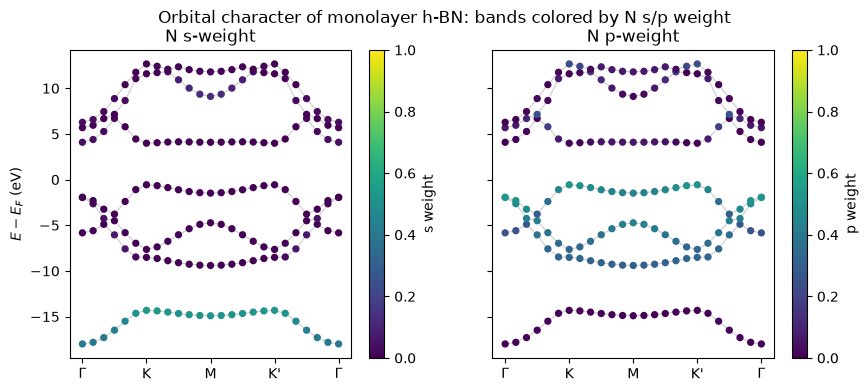

In [5]:
x = np.arange(len(path))
fig, axes = plt.subplots(1, 2, figsize=(10, 4), sharey=True)
for ax, weight, label in zip(axes, [s_weight, p_weight], ["s", "p"]):
    for band in range(energies.shape[1]):
        ax.plot(x, energies[:, band], color="0.8", linewidth=0.8, zorder=1)
    sc = ax.scatter(
        np.tile(x, energies.shape[1]), energies.T.ravel(), c=weight.T.ravel(),
        cmap="viridis", vmin=0, vmax=1, s=18, zorder=2,
    )
    ax.set_xticks(ticks)
    ax.set_xticklabels([r"$\Gamma$", "K", "M", "K'", r"$\Gamma$"])
    ax.set_title(f"N {label}-weight")
    fig.colorbar(sc, ax=ax, label=f"{label} weight")
axes[0].set_ylabel(r"$E-E_F$ (eV)")
fig.suptitle("Orbital character of monolayer h-BN: bands colored by N s/p weight")
plt.show()